In [ ]:
# --- Standard Libraries ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import shutil
import datetime
from typing import Any
import json
import time
import requests

# --- Azure Libraries ---
from azure.ai.ml import MLClient
from azure.identity import DefaultAzureCredential
from azure.ai.ml.entities import ManagedOnlineEndpoint, ManagedOnlineDeployment, Model
from azure.ai.ml.constants import AssetTypes
from azure.core.exceptions import ServiceResponseError

# --- ML Core & Models ---
from sklearn.ensemble import RandomForestClassifier, IsolationForest
import xgboost as xgb
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import precision_recall_curve, average_precision_score, recall_score, precision_score, f1_score, PrecisionRecallDisplay, confusion_matrix
import shap

# --- Experiment Tracking ---
import mlflow
import mlflow.sklearn
from mlflow.models import infer_signature

# --- Deployment ---
from fastapi import FastAPI


In [2]:
ml_client = MLClient.from_config(credential=DefaultAzureCredential())
print(f"Connected to Workspace: {ml_client.workspace_name}")

Found the config file in: /config.json


Connected to Workspace: cyfangus-machinelearn


In [3]:
def load_azure_csv(asset_name):
    # Use the "latest" label to always pull the newest data
    asset = ml_client.data.get(name=asset_name, label="latest")
    print(f"Loaded {asset_name} - Version: {asset.version}")
    return pd.read_csv(asset.path)

# Load Features
X_train = load_azure_csv("X-train")
X_test = load_azure_csv("X-test-final")

# Load Labels (and flatten to 1D array)
y_train = load_azure_csv("y-train").values.ravel()
y_test = load_azure_csv("y-test-final").values.ravel()

Loaded X-train - Version: 3
Loaded X-test-final - Version: 3
Loaded y-train - Version: 3
Loaded y-test-final - Version: 3


Overriding of current TracerProvider is not allowed
Overriding of current LoggerProvider is not allowed
Overriding of current MeterProvider is not allowed
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Overriding of current TracerProvider is not allowed
Overriding of current LoggerProvider is not allowed
Overriding of current MeterProvider is not allowed
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented


In [4]:
# Point MLflow to Azure ML Workspace
mlflow.set_tracking_uri(ml_client.workspaces.get(ml_client.workspace_name).mlflow_tracking_uri)

In [5]:
# Extract raw amount and drop for training isolation forest
raw_amounts_train = X_train['Amount'].values
raw_amounts_test = X_test['Amount'].values

X_train.drop('Amount', axis = 1, inplace = True)
X_test.drop('Amount', axis = 1, inplace = True)

In [6]:
# Setup Unique Experiment for  isolation forest training and anonmaly score generation 
timestamp = datetime.datetime.now().strftime("%Y%m%d-%H%M")
experiment_name = f"training-isolation-forest-{timestamp}"
mlflow.set_experiment(experiment_name)

# Train Isolation Forest on the training set (Unsupervised)
iso_forest = IsolationForest(contamination=0.05, random_state=42) # Set slightly higher
iso_forest.fit(X_train)

# Generate Anomaly Scores
# Values closer to -1 are more anomalous
X_train['anomaly_score'] = iso_forest.decision_function(X_train)
X_test['anomaly_score'] = iso_forest.decision_function(X_test)

2026/03/12 09:46:53 INFO mlflow.tracking.fluent: Experiment with name 'training-isolation-forest-20260312-0946' does not exist. Creating a new experiment.


In [7]:
def calculate_vdr_tdr(y_true, y_prob, amounts, epsilon=0.01):
    """
    Implements VDR and TDR logic.
    epsilon: fraction of total transactions to inspect (e.g., 1%).
    """
    n_inspect = int(len(y_true) * epsilon)
    total_fraud_value = np.sum(amounts[y_true == 1])
    total_fraud_count = np.sum(y_true == 1)
    
    # --- VDR Policy: Optimize for Value (Psi = Prob * Amount) ---
    psi_scores = y_prob * amounts
    vdr_threshold = np.sort(psi_scores)[-n_inspect]
    vdr_inspected = psi_scores >= vdr_threshold
    vdr_value_captured = np.sum(amounts[(y_true == 1) & vdr_inspected])
    vdr_score = vdr_value_captured / total_fraud_value # [cite: 79]
    
    # --- TDR Policy: Optimize for Count (Score = Prob) ---
    tdr_threshold = np.sort(y_prob)[-n_inspect]
    tdr_inspected = y_prob >= tdr_threshold
    tdr_value_captured = np.sum(amounts[(y_true == 1) & tdr_inspected])
    # TDR is essentially Recall at epsilon
    tdr_score = np.sum((y_true == 1) & tdr_inspected) / total_fraud_count 
    
    return vdr_score, tdr_score, vdr_value_captured, tdr_value_captured

In [8]:
def get_models():
    return {
        "Random_Forest": RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
        "XGBoost": xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=6, eval_metric='aucpr', random_state=42),
        "Logistic_Regression": LogisticRegression(max_iter=1000, solver='liblinear', random_state=42)
    }

In [10]:
timestamp = datetime.datetime.now().strftime("%Y%m%d-%H%M")
experiment1_name = f"Exp1_Frequency_Opt_{timestamp}"
mlflow.set_experiment(experiment1_name)

# Use a fixed weight for all fraud cases (Ratio = 578)
freq_weights = np.where(y_train == 1, 578, 1)

for model_name, model_obj in get_models().items():
    with mlflow.start_run(run_name=f"{model_name}-Freq-Opt"):
        model_obj.fit(X_train, y_train, sample_weight=freq_weights)
        
        # Get probabilities
        y_prob = model_obj.predict_proba(X_test)[:, 1]
        
        # Business Metrics (VDR/TDR)
        vdr, tdr, vdr_d, tdr_d = calculate_vdr_tdr(y_test, y_prob, raw_amounts_test, epsilon=0.01)
        
        # Operational Metrics @ 1% alert rate
        n_inspect = int(len(y_test) * 0.01)
        threshold_1pct = np.sort(y_prob)[-n_inspect]
        y_pred_1pct = (y_prob >= threshold_1pct).astype(int)
        
        prec_at_1 = precision_score(y_test, y_pred_1pct)
        rec_at_1 = recall_score(y_test, y_pred_1pct)
        
        # Efficieny index
        efficiency_idx = vdr / tdr if tdr > 0 else 0
        
        # False Positive Rate
        fp = np.sum((y_pred_1pct == 1) & (y_test == 0))
        total_legit = np.sum(y_test == 0)
        fpr = fp / total_legit
        
        # Global Technical Metrics
        auprc = average_precision_score(y_test, y_prob)

        # Log the metrics
        mlflow.log_metrics({
            "VDR_at_1pct": vdr,            # Financial
            "TDR_at_1pct": tdr,            # Operational Volume
            "USD_Saved": vdr_d,            # Bottom Line
            "Precision_at_1pct": prec_at_1, # Hit Rate
            "Recall_at_1pct": rec_at_1,    # Capture Rate
            "Efficiency_Index": efficiency_idx,
            "FPR_at_1pct": fpr,
            "AUPRC": auprc          # Overall Model Quality
        })
        
        print(f"✅ {model_name} | VDR: {vdr:.2%} | Efficiency: {efficiency_idx:.2f}")

2026/03/12 09:49:25 INFO mlflow.tracking.fluent: Experiment with name 'Exp1_Frequency_Opt_20260312-0949' does not exist. Creating a new experiment.


✅ Random_Forest | VDR: 91.85% | Efficiency: 1.02
🏃 View run Random_Forest-Freq-Opt at: https://eastus2.api.azureml.ms/mlflow/v2.0/subscriptions/86a6ee06-cdec-4f8f-bfc5-0e831cd3e9ca/resourceGroups/defaultresourcegroup-uksouth/providers/Microsoft.MachineLearningServices/workspaces/cyfangus-machinelearn/#/experiments/df386d38-a12a-4ff2-a147-ce282bd3d9a1/runs/68f9c03a-da3b-4fbf-a654-10e8497a06d7
🧪 View experiment at: https://eastus2.api.azureml.ms/mlflow/v2.0/subscriptions/86a6ee06-cdec-4f8f-bfc5-0e831cd3e9ca/resourceGroups/defaultresourcegroup-uksouth/providers/Microsoft.MachineLearningServices/workspaces/cyfangus-machinelearn/#/experiments/df386d38-a12a-4ff2-a147-ce282bd3d9a1
✅ XGBoost | VDR: 98.18% | Efficiency: 1.08
🏃 View run XGBoost-Freq-Opt at: https://eastus2.api.azureml.ms/mlflow/v2.0/subscriptions/86a6ee06-cdec-4f8f-bfc5-0e831cd3e9ca/resourceGroups/defaultresourcegroup-uksouth/providers/Microsoft.MachineLearningServices/workspaces/cyfangus-machinelearn/#/experiments/df386d38-a12a

In [11]:
timestamp = datetime.datetime.now().strftime("%Y%m%d-%H%M")
experiment2_name = f"Exp2_Raw_Value_Opt_{timestamp}"
mlflow.set_experiment(experiment2_name)

# Weight = Actual Dollars
value_weights = raw_amounts_train 

for model_name, model_obj in get_models().items():
    with mlflow.start_run(run_name=f"{model_name}-Raw-Value-Opt"):
        model_obj.fit(X_train, y_train, sample_weight=value_weights)
        
        # Get probabilities
        y_prob = model_obj.predict_proba(X_test)[:, 1]
        
        # Business Metrics (VDR/TDR)
        vdr, tdr, vdr_d, tdr_d = calculate_vdr_tdr(y_test, y_prob, raw_amounts_test, epsilon=0.01)
        
        # Operational Metrics @ 1% alert rate
        n_inspect = int(len(y_test) * 0.01)
        threshold_1pct = np.sort(y_prob)[-n_inspect]
        y_pred_1pct = (y_prob >= threshold_1pct).astype(int)
        
        prec_at_1 = precision_score(y_test, y_pred_1pct)
        rec_at_1 = recall_score(y_test, y_pred_1pct)
        
        # Efficieny index
        efficiency_idx = vdr / tdr if tdr > 0 else 0
        
        # False Positive Rate
        fp = np.sum((y_pred_1pct == 1) & (y_test == 0))
        total_legit = np.sum(y_test == 0)
        fpr = fp / total_legit
        
        # Global Technical Metrics
        auprc = average_precision_score(y_test, y_prob)

        # Log the metrics
        mlflow.log_metrics({
            "VDR_at_1pct": vdr,            # Financial
            "TDR_at_1pct": tdr,            # Operational Volume
            "USD_Saved": vdr_d,            # Bottom Line
            "Precision_at_1pct": prec_at_1, # Hit Rate
            "Recall_at_1pct": rec_at_1,    # Capture Rate
            "Efficiency_Index": efficiency_idx,
            "FPR_at_1pct": fpr,
            "AUPRC": auprc          # Overall Model Quality
        })
        
        print(f"✅ {model_name} | VDR: {vdr:.2%} | Efficiency: {efficiency_idx:.2f}")

2026/03/12 09:50:57 INFO mlflow.tracking.fluent: Experiment with name 'Exp2_Raw_Value_Opt_20260312-0950' does not exist. Creating a new experiment.


✅ Random_Forest | VDR: 93.66% | Efficiency: 1.04
🏃 View run Random_Forest-Raw-Value-Opt at: https://eastus2.api.azureml.ms/mlflow/v2.0/subscriptions/86a6ee06-cdec-4f8f-bfc5-0e831cd3e9ca/resourceGroups/defaultresourcegroup-uksouth/providers/Microsoft.MachineLearningServices/workspaces/cyfangus-machinelearn/#/experiments/bef6080d-bf9f-4981-b603-1bc727e3c2e1/runs/56c59b03-7035-4b0d-8591-b8716d78219b
🧪 View experiment at: https://eastus2.api.azureml.ms/mlflow/v2.0/subscriptions/86a6ee06-cdec-4f8f-bfc5-0e831cd3e9ca/resourceGroups/defaultresourcegroup-uksouth/providers/Microsoft.MachineLearningServices/workspaces/cyfangus-machinelearn/#/experiments/bef6080d-bf9f-4981-b603-1bc727e3c2e1
✅ XGBoost | VDR: 81.11% | Efficiency: 0.96
🏃 View run XGBoost-Raw-Value-Opt at: https://eastus2.api.azureml.ms/mlflow/v2.0/subscriptions/86a6ee06-cdec-4f8f-bfc5-0e831cd3e9ca/resourceGroups/defaultresourcegroup-uksouth/providers/Microsoft.MachineLearningServices/workspaces/cyfangus-machinelearn/#/experiments/bef

In [12]:
timestamp = datetime.datetime.now().strftime("%Y%m%d-%H%M")
experiment3_name = f"Exp3_Balanced_Value_Opt_{timestamp}"
mlflow.set_experiment(experiment3_name)

# Log transformation to dampen noise + Class multiplier for signal
balanced_weights = np.where(
    y_train == 1, 
    np.log1p(raw_amounts_train) * 500, # Signal Boost
    np.log1p(raw_amounts_train)        # Dampened Noise
)

for model_name, model_obj in get_models().items():
    with mlflow.start_run(run_name=f"{model_name}-Balanced-Value-Opt"):
        model_obj.fit(X_train, y_train, sample_weight=balanced_weights)
        
        # Get probabilities
        y_prob = model_obj.predict_proba(X_test)[:, 1]
        
        # Business Metrics (VDR/TDR)
        vdr, tdr, vdr_d, tdr_d = calculate_vdr_tdr(y_test, y_prob, raw_amounts_test, epsilon=0.01)
        
        # Operational Metrics @ 1% alert rate
        n_inspect = int(len(y_test) * 0.01)
        threshold_1pct = np.sort(y_prob)[-n_inspect]
        y_pred_1pct = (y_prob >= threshold_1pct).astype(int)
        
        prec_at_1 = precision_score(y_test, y_pred_1pct)
        rec_at_1 = recall_score(y_test, y_pred_1pct)
        
        # Efficieny index
        efficiency_idx = vdr / tdr if tdr > 0 else 0
        
        # False Positive Rate
        fp = np.sum((y_pred_1pct == 1) & (y_test == 0))
        total_legit = np.sum(y_test == 0)
        fpr = fp / total_legit
        
        # Global Technical Metrics
        auprc = average_precision_score(y_test, y_prob)

        # Log the metrics
        mlflow.log_metrics({
            "VDR_at_1pct": vdr,            # Financial
            "TDR_at_1pct": tdr,            # Operational Volume
            "USD_Saved": vdr_d,            # Bottom Line
            "Precision_at_1pct": prec_at_1, # Hit Rate
            "Recall_at_1pct": rec_at_1,    # Capture Rate
            "Efficiency_Index": efficiency_idx,
            "FPR_at_1pct": fpr,
            "AUPRC": auprc          # Overall Model Quality
        })
        
        print(f"✅ {model_name} | VDR: {vdr:.2%} | Efficiency: {efficiency_idx:.2f}")

2026/03/12 09:52:52 INFO mlflow.tracking.fluent: Experiment with name 'Exp3_Balanced_Value_Opt_20260312-0952' does not exist. Creating a new experiment.


✅ Random_Forest | VDR: 92.85% | Efficiency: 1.03
🏃 View run Random_Forest-Balanced-Value-Opt at: https://eastus2.api.azureml.ms/mlflow/v2.0/subscriptions/86a6ee06-cdec-4f8f-bfc5-0e831cd3e9ca/resourceGroups/defaultresourcegroup-uksouth/providers/Microsoft.MachineLearningServices/workspaces/cyfangus-machinelearn/#/experiments/ba4e9ef5-405c-402a-a55a-a3033d8cec06/runs/f82fc621-d132-4289-a8d8-2e83afa7ac21
🧪 View experiment at: https://eastus2.api.azureml.ms/mlflow/v2.0/subscriptions/86a6ee06-cdec-4f8f-bfc5-0e831cd3e9ca/resourceGroups/defaultresourcegroup-uksouth/providers/Microsoft.MachineLearningServices/workspaces/cyfangus-machinelearn/#/experiments/ba4e9ef5-405c-402a-a55a-a3033d8cec06
✅ XGBoost | VDR: 87.53% | Efficiency: 0.96
🏃 View run XGBoost-Balanced-Value-Opt at: https://eastus2.api.azureml.ms/mlflow/v2.0/subscriptions/86a6ee06-cdec-4f8f-bfc5-0e831cd3e9ca/resourceGroups/defaultresourcegroup-uksouth/providers/Microsoft.MachineLearningServices/workspaces/cyfangus-machinelearn/#/exper

In [14]:
time.sleep(30) 

experiment_names = [experiment1_name, experiment2_name, experiment3_name]
all_runs = []

for exp_name in experiment_names:
    exp = mlflow.get_experiment_by_name(exp_name)
    if exp:
        runs = mlflow.search_runs(experiment_ids=[exp.experiment_id])
        strategy_map = {"Exp1": "Frequency", "Exp2": "Raw Value", "Exp3": "Balanced"}
        prefix = exp_name.split('_')[0]
        runs['Strategy'] = strategy_map.get(prefix, prefix)
        all_runs.append(runs)

leaderboard_df = pd.concat(all_runs, ignore_index=True)

mapping = {
    'Strategy': 'Strategy',
    'tags.mlflow.runName': 'Model_Run',
    'metrics.VDR_at_1pct': 'VDR (Value %)',
    'metrics.USD_Saved': 'USD Saved',
    'metrics.Precision_at_1pct': 'Hit Rate (Prec@1%)',
    'metrics.TDR_at_1pct': 'Recall@1% (TDR)',
    'metrics.FPR_at_1pct': 'Customer Friction (FPR)',
    'metrics.Efficiency_Index': 'Value Efficiency',
    'metrics.AUPRC_Global': 'Global AUPRC',
    'metrics.Log_Loss_Global': 'Log Loss'
}

# Filter and Rename
existing_cols = [col for col in mapping.keys() if col in leaderboard_df.columns]
leaderboard = leaderboard_df[existing_cols].rename(columns=mapping)

# Calculate Estimated Net Profit
# Assuming $10 cost per false positive investigation
# We estimate FP count as: FPR * (Total Test Set Size - Total Fraud in Test Set)
total_test_size = len(y_test)
total_fraud_test = sum(y_test)
cost_per_fp = 10.0 

if 'Customer Friction (FPR)' in leaderboard.columns and 'USD Saved' in leaderboard.columns:
    leaderboard['Est_Ops_Cost'] = (leaderboard['Customer Friction (FPR)'] * (total_test_size - total_fraud_test) * cost_per_fp)
    leaderboard['Net_Financial_Impact'] = leaderboard['USD Saved'] - leaderboard['Est_Ops_Cost']

# Final Polish
if 'VDR (Value %)' in leaderboard.columns:
    # Sort by Net Financial Impact if available, otherwise VDR
    sort_col = 'Net_Financial_Impact' if 'Net_Financial_Impact' in leaderboard.columns else 'VDR (Value %)'
    leaderboard = leaderboard.sort_values(by=sort_col, ascending=False).reset_index(drop=True)
    
    display_df = leaderboard.copy()
    
    # Format Percentages
    pct_cols = ['VDR (Value %)', 'Hit Rate (Prec@1%)', 'Recall@1% (TDR)', 'Customer Friction (FPR)', 'Global AUPRC']
    for col in pct_cols:
        if col in display_df.columns:
            display_df[col] = display_df[col].apply(lambda x: f"{x:.2%}" if pd.notnull(x) else "N/A")
            
    # Format Currency
    curr_cols = ['USD Saved', 'Est_Ops_Cost', 'Net_Financial_Impact']
    for col in curr_cols:
        if col in display_df.columns:
            display_df[col] = display_df[col].apply(lambda x: f"${x:,.2f}" if pd.notnull(x) else "N/A")

print("🏆 PROJECT MASTER LEADERBOARD: Business Strategy Evaluation")
display(display_df)

🏆 PROJECT MASTER LEADERBOARD: Business Strategy Evaluation


,Strategy,Model_Run,VDR (Value %),USD Saved,Hit Rate (Prec@1%),Recall@1% (TDR),Customer Friction (FPR),Value Efficiency,Est_Ops_Cost,Net_Financial_Impact
0,Frequency,XGBoost-Freq-Opt,98.18%,"$10,451.05",15.64%,90.82%,0.84%,1.081068,"$4,800.00","$5,651.05"
1,Raw Value,Random_Forest-Raw-Value-Opt,93.66%,"$9,969.78",15.47%,89.80%,0.85%,1.043004,"$4,810.00","$5,159.78"
2,Balanced,Random_Forest-Balanced-Value-Opt,92.85%,"$9,883.70",15.47%,89.80%,0.85%,1.033999,"$4,810.00","$5,073.70"
3,Frequency,Random_Forest-Freq-Opt,91.85%,"$9,777.44",15.47%,89.80%,0.85%,1.022883,"$4,810.00","$4,967.44"
4,Balanced,XGBoost-Balanced-Value-Opt,87.53%,"$9,317.02",15.64%,90.82%,0.84%,0.963763,"$4,800.00","$4,517.02"
5,Raw Value,Logistic_Regression-Raw-Value-Opt,87.29%,"$9,292.24",15.29%,88.78%,0.85%,0.983296,"$4,820.00","$4,472.24"
6,Raw Value,XGBoost-Raw-Value-Opt,81.11%,"$8,633.73",14.59%,84.69%,0.85%,0.957643,"$4,860.00","$3,773.73"
7,Balanced,Logistic_Regression-Balanced-Value-Opt,74.10%,"$7,888.30",15.29%,88.78%,0.85%,0.834733,"$4,820.00","$3,068.30"
8,Frequency,Logistic_Regression-Freq-Opt,66.09%,"$7,034.84",15.47%,89.80%,0.85%,0.735961,"$4,810.00","$2,224.84"


Active Run ID: 94a597fd-5526-4ee3-99c1-ef38a2f05cb2


PermutationExplainer explainer: 101it [00:11,  1.15it/s]                         


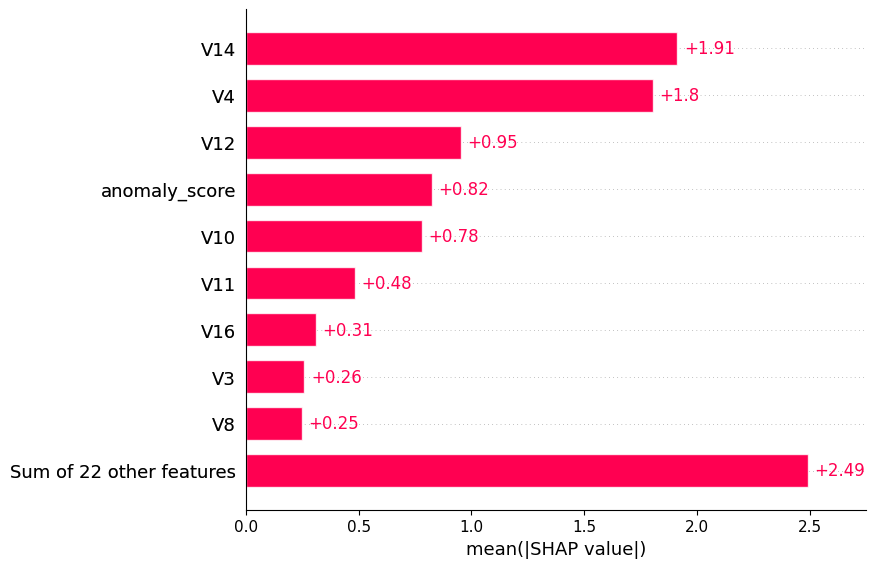

🏃 View run Training_with_SHAP_Analysis at: https://eastus2.api.azureml.ms/mlflow/v2.0/subscriptions/86a6ee06-cdec-4f8f-bfc5-0e831cd3e9ca/resourceGroups/defaultresourcegroup-uksouth/providers/Microsoft.MachineLearningServices/workspaces/cyfangus-machinelearn/#/experiments/0ec0e4f7-1878-4277-9986-c056fcaef4dd/runs/94a597fd-5526-4ee3-99c1-ef38a2f05cb2
🧪 View experiment at: https://eastus2.api.azureml.ms/mlflow/v2.0/subscriptions/86a6ee06-cdec-4f8f-bfc5-0e831cd3e9ca/resourceGroups/defaultresourcegroup-uksouth/providers/Microsoft.MachineLearningServices/workspaces/cyfangus-machinelearn/#/experiments/0ec0e4f7-1878-4277-9986-c056fcaef4dd
Training Complete. Files are in Azure Run: 94a597fd-5526-4ee3-99c1-ef38a2f05cb2


In [44]:
mlflow.set_experiment("Fraud_Detection_XGB_Champion")

with mlflow.start_run(run_name="Training_with_SHAP_Analysis") as run:
    # Capture the run_id for later registration
    active_run_id = run.info.run_id
    print(f"Active Run ID: {active_run_id}")

    mlflow.log_params(best_model.get_params())
    
    best_model = xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=6, eval_metric='aucpr', random_state=42)
    best_model.fit(X_train, y_train, sample_weight=freq_weights)

    # Enriching samples for contrast in SHAP analysis
    X_test_fraud = X_test[y_test == 1].sample(min(50, sum(y_test)), random_state=42)
    X_test_legit = X_test[y_test == 0].sample(50, random_state=42)
    X_test_enriched = pd.concat([X_test_fraud, X_test_legit])

    model_func_logit = lambda x: best_model.get_booster().predict(xgb.DMatrix(x), output_margin=True)
    masker = shap.maskers.Independent(X_train, max_samples=100)
    explainer = shap.Explainer(model_func_logit, masker)

    shap_values_enriched = explainer(X_test_enriched)

    # Plot
    shap.plots.bar(shap_values_enriched, show=False)
    plt.savefig("shap_bar_importance.png", bbox_inches='tight')
    mlflow.log_artifact("shap_bar_importance.png")
    plt.show()
    plt.close()

    model_local_path = "outputs/model"
    os.makedirs(model_local_path, exist_ok=True)
    
    # Save the XGBoost model file
    best_model.save_model(os.path.join(model_local_path, "model.json"))
    
    # Save the threshold as metadata in a text file
    with open(os.path.join(model_local_path, "business_config.json"), "w") as f:
        json.dump({"threshold": float(business_threshold)}, f)

    # Log the entire folder as an artifact (this uses a different, stable API)
    mlflow.log_artifacts(model_local_path, artifact_path="model_files")

print(f"Training Complete. Files are in Azure Run: {active_run_id}")

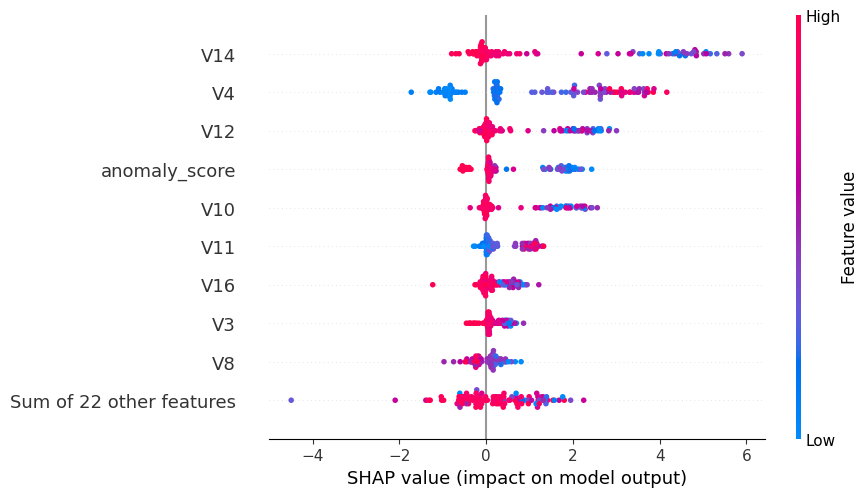

In [25]:
# Beeswarm plot
plt.figure(figsize=(10, 6))
shap.plots.beeswarm(shap_values_enriched)

In [45]:
# Threshold tuning for a 1% alert rate business case
# Get probabilities
y_probs = best_model.predict_proba(X_test)[:, 1]

# Find the threshold that results in exactly a 1% Alert Rate
# Sort probabilities and find the 99th percentile value
alert_rate_goal = 0.01 
business_threshold = np.percentile(y_probs, 100 * (1 - alert_rate_goal))

# Calculate metrics at this specific business threshold
y_pred_business = (y_probs >= business_threshold).astype(int)
from sklearn.metrics import precision_score, recall_score

prec = precision_score(y_test, y_pred_business)
rec = recall_score(y_test, y_pred_business)

print(f"--- Business-Constraint Tuning (1% Alert Cap) ---")
print(f"Operational Threshold: {business_threshold:.4f}")
print(f"Precision (Hit Rate): {prec:.2%}")
print(f"Recall (Fraud Captured): {rec:.2%}")

# Log THIS version to MLflow
with mlflow.start_run(run_name="Business-Threshold-Optimization"):
    mlflow.log_param("Alert_Cap_Percent", "1%")
    mlflow.log_param("Operating_Threshold", business_threshold)
    mlflow.log_metric("Business_Precision", prec)
    mlflow.log_metric("Business_Recall", rec)

--- Business-Constraint Tuning (1% Alert Cap) ---
Operational Threshold: 0.0333
Precision (Hit Rate): 15.61%
Recall (Fraud Captured): 90.82%
🏃 View run Business-Threshold-Optimization at: https://eastus2.api.azureml.ms/mlflow/v2.0/subscriptions/86a6ee06-cdec-4f8f-bfc5-0e831cd3e9ca/resourceGroups/defaultresourcegroup-uksouth/providers/Microsoft.MachineLearningServices/workspaces/cyfangus-machinelearn/#/experiments/0ec0e4f7-1878-4277-9986-c056fcaef4dd/runs/3c225bb5-c9c2-4894-bd2a-0758faf87ad4
🧪 View experiment at: https://eastus2.api.azureml.ms/mlflow/v2.0/subscriptions/86a6ee06-cdec-4f8f-bfc5-0e831cd3e9ca/resourceGroups/defaultresourcegroup-uksouth/providers/Microsoft.MachineLearningServices/workspaces/cyfangus-machinelearn/#/experiments/0ec0e4f7-1878-4277-9986-c056fcaef4dd


In [ ]:
# Curve data
precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs)

n_total             = len(y_probs)
alert_rates         = np.array([np.sum(y_probs >= t) / n_total for t in thresholds])
business_alert_rate = np.sum(y_probs >= business_threshold) / n_total

# Reverse so x-axis reads low → high alert rate (left to right)
alert_rates_plot = alert_rates[::-1]
precisions_plot  = precisions[:-1][::-1]
recalls_plot     = recalls[:-1][::-1]

# F1-max point — model's natural sweet spot (where precision == recall)
f1_scores     = 2 * precisions_plot * recalls_plot / (precisions_plot + recalls_plot + 1e-10)
f1_max_idx    = np.argmax(f1_scores)
f1_alert_rate = alert_rates_plot[f1_max_idx]
f1_prec       = precisions_plot[f1_max_idx]
f1_rec        = recalls_plot[f1_max_idx]
f1_score_val  = f1_scores[f1_max_idx]

# Interpolated values at the 1% cap for accurate arrow tips
op_prec = float(np.interp(business_alert_rate, alert_rates_plot, precisions_plot))
op_rec  = float(np.interp(business_alert_rate, alert_rates_plot, recalls_plot))

print(f'F1-Max → Alert Rate: {f1_alert_rate:.2%} | P: {f1_prec:.2%} | R: {f1_rec:.2%} | F1: {f1_score_val:.2%}')

# ── Plot ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(alert_rates_plot, precisions_plot, color='steelblue', linewidth=2, label='Precision (Hit Rate)')
ax.plot(alert_rates_plot, recalls_plot,    color='seagreen',  linewidth=2, label='Recall (Capture Rate)')

# Zone shading
ax.axvspan(0, f1_alert_rate,                    color='mediumpurple', alpha=0.10, label=f'Model Sweet Spot (≤{f1_alert_rate:.1%})')
ax.axvspan(f1_alert_rate, business_alert_rate,  color='salmon',       alpha=0.12, label=f'Operational Buffer ({f1_alert_rate:.1%}–{business_alert_rate:.1%})')

# Vertical lines
ax.axvline(f1_alert_rate,       color='mediumpurple', linestyle='--', linewidth=1.5, label=f'F1 Max — balanced threshold ({f1_alert_rate:.1%})')
ax.axvline(business_alert_rate, color='crimson',      linestyle='--', linewidth=1.5, label='Operational Cap — 1% alert rate')

# Dot markers
ax.plot(f1_alert_rate,       f1_prec, 'o', color='mediumpurple', markersize=7, zorder=5)
ax.plot(f1_alert_rate,       f1_rec,  'o', color='mediumpurple', markersize=7, zorder=5)
ax.plot(business_alert_rate, op_prec, 'o', color='crimson',      markersize=7, zorder=5)
ax.plot(business_alert_rate, op_rec,  'o', color='crimson',      markersize=7, zorder=5)

# Annotations
ax.annotate(
    f'F1 Max\nP={f1_prec:.0%}  R={f1_rec:.0%}\nF1={f1_score_val:.0%}',
    xy=(f1_alert_rate, (f1_prec + f1_rec) / 2),
    xytext=(f1_alert_rate + 0.008, 0.55), fontsize=9, color='mediumpurple',
    arrowprops=dict(arrowstyle='->', color='mediumpurple', lw=1.2),
    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='mediumpurple', alpha=0.85)
)
ax.annotate(
    f'Operational Cap\nP={prec:.0%}  R={rec:.0%}',
    xy=(business_alert_rate, (op_prec + op_rec) / 2),
    xytext=(business_alert_rate + 0.008, 0.30), fontsize=9, color='crimson',
    arrowprops=dict(arrowstyle='->', color='crimson', lw=1.2),
    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='crimson', alpha=0.85)
)

ax.set_xlim([0, 0.10])
ax.set_ylim([0, 1.05])
ax.set_xlabel('Alert Rate (% of transactions flagged)', fontsize=12)
ax.set_ylabel('Score (0.0 – 1.0)', fontsize=12)
ax.set_title('Threshold Tuning: Balancing Fraud Capture vs. Operational Capacity', fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=8, frameon=True)
ax.grid(True, linestyle=':', alpha=0.6)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))

plt.tight_layout()
plt.show()


In [48]:
model_name = "fraud-XGB-champion"

# Point to the artifact folder we manually uploaded
# Note: we used 'model_files' as the artifact_path in the previous step
run_model_path = "runs:/94a597fd-5526-4ee3-99c1-ef38a2f05cb2/model_files"

# Define the Model Asset
model_asset = Model(
    path=run_model_path,
    name=model_name,
    description="XGBoost model with SHAP analysis and tuned business threshold",
    type=AssetTypes.CUSTOM_MODEL
)

# Register it
registered_model = ml_client.models.create_or_update(model_asset)

print(f"✅ Model registered! Version: {registered_model.version}")

✅ Model registered! Version: 1
